# Transformed Observations Analysis

This notebook runs analysis on transformed detections using the Ray cluster.

Currently includes:
- **Linearity Analysis**: Computes R² for object tracks in gnomonic coordinates

Future analyses can be added here as needed.

## Connect to Ray Cluster

In [40]:
import sys
from pathlib import Path

# Add adam-thor-research to path
adam_thor_research_path = Path('../adam-thor-research').resolve()
sys.path.insert(0, str(adam_thor_research_path))

import adam_core
import thor
import os
import ray
from datetime import datetime

# Set the RAY_ADDRESS environment variable
os.environ['RAY_ADDRESS'] = 'ray://34.118.238.105:10001'
os.environ['RAY_NAMESPACE'] = 'ai-aleck'
os.environ['RAY_PUT_PROXY_BUCKET'] = 'thor-research'

# Ignore Ray version mismatch (cluster is 2.52.1, local might be 2.51.1)
os.environ['RAY_IGNORE_VERSION_MISMATCH'] = '1'

# Only initialize if not already connected
if not ray.is_initialized():
    ray.init(
        address=os.environ['RAY_ADDRESS'],
        namespace=os.environ['RAY_NAMESPACE'],
        runtime_env={
            "py_modules": [adam_core, thor],
            # Don't specify pip - use cluster's existing packages
        }
    )
    print("Connected to Ray cluster")
else:
    print("Already connected to Ray cluster")

print(f"Available resources: {ray.cluster_resources()}")

2025-12-11 16:28:51,558	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver
SIGTERM handler is not set because current thread is not the main thread.
2025-12-11 16:28:53,217	WARNING utils.py:1324 -- Version mismatch: The cluster was started with:
    Ray: 2.52.1
    Python: 3.12.3
This process on Ray Client was started with:
    Ray: 2.51.1
    Python: 3.12.12



Connected to Ray cluster
Available resources: {'node:10.32.27.66': 1.0, 'node:__internal_head__': 1.0, 'node:10.32.32.130': 1.0, 'node:10.32.7.66': 1.0, 'node:10.32.44.66': 1.0, 'node:10.32.67.2': 1.0, 'link_test_orbit': 24.0, 'node:10.32.3.66': 1.0, 'node:10.32.1.5': 1.0, 'node:10.108.3.2': 1.0, 'node:10.32.2.130': 1.0, 'node:10.32.45.130': 1.0, 'node:10.32.42.66': 1.0, 'memory': 1434519076864.0, 'node:10.32.10.130': 1.0, 'node:10.32.0.194': 1.0, 'node:10.32.0.7': 1.0, 'node:10.32.37.66': 1.0, 'node:10.32.58.194': 1.0, 'node:10.32.3.2': 1.0, 'object_store_memory': 535660986770.0, 'node:10.32.19.66': 1.0, 'node:10.32.67.66': 1.0, 'CPU': 370.0, 'node:10.32.2.194': 1.0, 'node:10.32.43.130': 1.0, 'node:10.32.23.194': 1.0, 'node:10.32.4.194': 1.0, 'node:10.32.37.130': 1.0, 'node:10.32.4.66': 1.0, 'node:10.32.5.194': 1.0, 'node:10.32.26.130': 1.0}


In [41]:
ray.shutdown()

## Configuration

Set parameters for the analysis run:

In [42]:
# BigQuery configuration
PROJECT_ID = "moeyens-thor-dev"
ANALYSIS_OBS_TABLE = "moeyens-thor-dev.thor_v3.source_catalog_nov25"
TRANSFORMED_TABLE = "moeyens-thor-dev.thor_v3.thor_dec9_thor_spilling_10_processes_transformed_detections"

# Analysis parameters
MIN_OBS_PER_ORBIT = 6
CHECKPOINT_EVERY = 10  # Checkpoint every N test orbits
PARALLEL_WORKERS = 5  # Number of orbits to process in parallel (1 = sequential, 5-10 recommended)

# Output configuration
run_id = datetime.now().strftime("%Y%m%d_%H%M%S")
CHECKPOINT_PATH = f"gs://thor-research/analysis/linearity_results_{run_id}.parquet"

# Testing: set MAX_ORBITS to a small number for testing (None = process all)
MAX_ORBITS = 10  # Change to None for full run

print(f"Run ID: {run_id}")
print(f"Mode: {'TEST (10 orbits)' if MAX_ORBITS else 'FULL RUN'}")
print(f"Parallel workers: {PARALLEL_WORKERS}")
print(f"Results will be written to: {CHECKPOINT_PATH}")

Run ID: 20251211_162853
Mode: TEST (10 orbits)
Parallel workers: 5
Results will be written to: gs://thor-research/analysis/linearity_results_20251211_162853.parquet


## Run Linearity and Velocity Analysis

This will process all test orbits and compute linearity and velocity metrics **on the Ray cluster**.

### How Parallelization Works:

With `PARALLEL_WORKERS=5`, the orbits are split into 5 chunks:
- **Worker 0**: Orbits 1-500 (processes independently, checkpoints every 10)
- **Worker 1**: Orbits 501-1000 (processes independently, checkpoints every 10)
- **Worker 2**: Orbits 1001-1500 (processes independently, checkpoints every 10)
- **Worker 3**: Orbits 1501-2000 (processes independently, checkpoints every 10)
- **Worker 4**: Orbits 2001-2500 (processes independently, checkpoints every 10)

All 5 workers run **simultaneously** without waiting for each other, making it truly ~5x faster.

**Efficiency**: Each worker processes its chunk independently. No waiting for slow orbits to finish before starting the next batch!

**Checkpointing**: Each worker saves its progress to a separate checkpoint file (e.g., `_worker0_checkpoint.parquet`). At the end, all are combined into the final result.

**Note**: While the computation runs on the cluster, you still need to keep this notebook connected until completion. The `ray.get()` call below will wait for all workers to finish and return the combined result.

In [43]:
# Define all analysis functions directly in the notebook
@ray.remote
def run_linearity_analysis_remote(
    project_id,
    analysis_obs_table,
    transformed_table,
    min_obs_per_orbit,
    checkpoint_path,
    checkpoint_every,
    max_orbits,
    parallel_workers,
):
    """Run linearity analysis on the Ray cluster - all code inline."""
    import numpy as np
    import pandas as pd
    from google.cloud import bigquery
    from typing import Optional
    import ray
    
    def compute_linearity_and_velocity(group: pd.DataFrame) -> pd.Series:
        """Compute linearity and velocity metrics for one object."""
        # BigQuery aliases td.coordinates.theta_x as just theta_x
        x = group["theta_x"].to_numpy()
        y = group["theta_y"].to_numpy()
        n = len(x)
        
        # Get time information (days + nanos)
        time_days = group["time_days"].to_numpy()
        time_nanos = group["time_nanos"].to_numpy()
        # Convert to fractional days
        times = time_days + time_nanos / 1e9 / 86400.0
        
        if n < 2:
            return pd.Series({
                "n_obs": n, 
                "linearity_r2": np.nan,
                "velocity_theta_x": np.nan,
                "velocity_theta_y": np.nan,
            })

        # Linearity calculation
        m, b = np.polyfit(x, y, 1)
        y_hat = m * x + b
        ss_res = np.sum((y - y_hat) ** 2)
        ss_tot = np.sum((y - y.mean()) ** 2)
        r2 = 1 - ss_res / ss_tot if ss_tot > 0 else 1.0

        # Velocity calculation: (last - first) / time_diff
        # Sort by time to ensure we get first and last
        sorted_idx = np.argsort(times)
        first_idx = sorted_idx[0]
        last_idx = sorted_idx[-1]
        
        dt = times[last_idx] - times[first_idx]  # days
        
        if dt > 0:
            vx = (x[last_idx] - x[first_idx]) / dt  # deg/day
            vy = (y[last_idx] - y[first_idx]) / dt  # deg/day
        else:
            vx = np.nan
            vy = np.nan

        return pd.Series({
            "n_obs": n, 
            "linearity_r2": r2,
            "velocity_theta_x": vx,
            "velocity_theta_y": vy,
        })

    def process_single_orbit(
        test_orbit_id: str,
        project_id: str,
        analysis_obs_table: str,
        transformed_table: str,
        min_obs_per_orbit: int,
    ) -> Optional[pd.DataFrame]:
        """Process a single test orbit and return linearity results."""
        bqclient = bigquery.Client(project=project_id)
        
        query = f"""
        WITH labeled_detections AS (
          SELECT
            td.id,
            td.night,
            td.coordinates.theta_x,
            td.coordinates.theta_y,
            td.coordinates.time.days AS time_days,
            td.coordinates.time.nanos AS time_nanos,
            td.state_id,
            td.test_orbit_id,
            ao.object_id
          FROM `{transformed_table}` td
          INNER JOIN `{analysis_obs_table}` ao
            ON td.id = ao.id
          WHERE td.test_orbit_id = @test_orbit_id
            AND ao.object_id IS NOT NULL
        ),
        object_counts AS (
          SELECT object_id, COUNT(*) as n_obs
          FROM labeled_detections
          GROUP BY object_id
          HAVING n_obs >= @min_obs
        )
        SELECT ld.*
        FROM labeled_detections ld
        INNER JOIN object_counts oc
          ON ld.object_id = oc.object_id
        """
        
        job_config = bigquery.QueryJobConfig(
            query_parameters=[
                bigquery.ScalarQueryParameter("test_orbit_id", "STRING", test_orbit_id),
                bigquery.ScalarQueryParameter("min_obs", "INT64", min_obs_per_orbit),
            ]
        )
        
        df = bqclient.query(query, job_config=job_config).to_dataframe()
        
        if df.empty:
            return None
        
        summary = (
            df
            .groupby("object_id")
            .apply(compute_linearity_and_velocity, include_groups=False)
            .reset_index()
        )
        summary["test_orbit_id"] = test_orbit_id
        summary = summary[["test_orbit_id", "object_id", "n_obs", "linearity_r2", "velocity_theta_x", "velocity_theta_y"]]
        
        return summary

    def write_results(df: pd.DataFrame, path: str) -> None:
        """Write results to GCS or local path."""
        df.to_parquet(path, index=False)
    
    # Main analysis logic
    print(f"Starting linearity analysis...")
    print(f"  Parallel workers: {parallel_workers}")
    if max_orbits:
        print(f"  Max orbits: {max_orbits} (testing mode)")

    bqclient = bigquery.Client(project=project_id)
    
    test_orbits_sql = f"""
    SELECT DISTINCT test_orbit_id
    FROM `{transformed_table}`
    ORDER BY test_orbit_id
    """
    if max_orbits:
        test_orbits_sql += f"\nLIMIT {max_orbits}"

    test_orbit_ids = [row.test_orbit_id for row in bqclient.query(test_orbits_sql)]
    print(f"Found {len(test_orbit_ids)} test orbits to process.")

    all_summaries = []

    if parallel_workers > 1:
        @ray.remote
        def process_orbit_chunk(
            chunk_id,
            orbit_ids_chunk,
            project_id,
            analysis_obs_table,
            transformed_table,
            min_obs_per_orbit,
            checkpoint_path_base,
            checkpoint_every,
        ):
            """Process a chunk of orbits independently."""
            chunk_summaries = []
            
            for i, orbit_id in enumerate(orbit_ids_chunk, start=1):
                summary = process_single_orbit(
                    orbit_id,
                    project_id,
                    analysis_obs_table,
                    transformed_table,
                    min_obs_per_orbit,
                )
                
                if summary is not None:
                    chunk_summaries.append(summary)
                
                if len(chunk_summaries) > 0 and len(chunk_summaries) % checkpoint_every == 0:
                    chunk_results = pd.concat(chunk_summaries, ignore_index=True)
                    chunk_checkpoint_path = checkpoint_path_base.replace('.parquet', f'_worker{chunk_id}_checkpoint.parquet')
                    write_results(chunk_results, chunk_checkpoint_path)
                    print(f"  Worker {chunk_id}: Checkpointed {len(chunk_results)} rows after {i}/{len(orbit_ids_chunk)} orbits")
            
            if chunk_summaries:
                return pd.concat(chunk_summaries, ignore_index=True)
            return pd.DataFrame()
        
        chunk_size = len(test_orbit_ids) // parallel_workers
        if len(test_orbit_ids) % parallel_workers != 0:
            chunk_size += 1
        
        chunks = []
        for i in range(parallel_workers):
            start_idx = i * chunk_size
            end_idx = min((i + 1) * chunk_size, len(test_orbit_ids))
            if start_idx < len(test_orbit_ids):
                chunks.append(test_orbit_ids[start_idx:end_idx])
        
        print(f"\nSplitting {len(test_orbit_ids)} orbits across {len(chunks)} workers")
        for i, chunk in enumerate(chunks):
            print(f"  Worker {i}: {len(chunk)} orbits")
        
        refs = [
            process_orbit_chunk.remote(
                i,
                chunk,
                project_id,
                analysis_obs_table,
                transformed_table,
                min_obs_per_orbit,
                checkpoint_path,
                checkpoint_every,
            )
            for i, chunk in enumerate(chunks)
        ]
        
        chunk_results = ray.get(refs)
        
        non_empty_results = [df for df in chunk_results if not df.empty]
        if non_empty_results:
            all_summaries = [pd.concat(non_empty_results, ignore_index=True)]
    else:
        for i, test_orbit_id in enumerate(test_orbit_ids, start=1):
            print(f"\nProcessing {i}/{len(test_orbit_ids)}: {test_orbit_id}")
            
            summary = process_single_orbit(
                test_orbit_id,
                project_id,
                analysis_obs_table,
                transformed_table,
                min_obs_per_orbit,
            )
            
            if summary is not None:
                all_summaries.append(summary)

            if len(all_summaries) % checkpoint_every == 0:
                all_results = pd.concat(all_summaries, ignore_index=True)
                write_results(all_results, checkpoint_path)
                print(f"  ✓ Checkpointed {len(all_results)} rows after {i} orbits")

    if all_summaries:
        all_results = pd.concat(all_summaries, ignore_index=True)
        write_results(all_results, checkpoint_path)
        print(f"\n✓ Analysis complete! {len(all_results)} rows written to {checkpoint_path}")
        return checkpoint_path
    else:
        print("\nNo objects with sufficient observations found.")
        return None

# Submit the job to the cluster with explicit runtime environment for the task
print("Submitting analysis job to Ray cluster...")

result_ref = run_linearity_analysis_remote.options(
    runtime_env={
        "pip": [
            "google-cloud-bigquery",
            "db-dtypes",
        ]
    }
).remote(
    project_id=PROJECT_ID,
    analysis_obs_table=ANALYSIS_OBS_TABLE,
    transformed_table=TRANSFORMED_TABLE,
    min_obs_per_orbit=MIN_OBS_PER_ORBIT,
    checkpoint_path=CHECKPOINT_PATH,
    checkpoint_every=CHECKPOINT_EVERY,
    max_orbits=MAX_ORBITS,
    parallel_workers=PARALLEL_WORKERS,
)

print(f"✓ Job submitted to cluster!")
print(f"Job reference: {result_ref}")
print(f"\nWaiting for job to complete...")
print(f"(This will stream progress from the cluster)\n")

# Wait for the result (this will block until complete, but job runs on cluster)
result_path = ray.get(result_ref)

print(f"\n✓ Analysis complete!")
print(f"Results saved to: {result_path}")

2025-12-11 16:28:53,488	INFO worker.py:1691 -- Using address ray://34.118.238.105:10001 set in the environment variable RAY_ADDRESS


Submitting analysis job to Ray cluster...


2025-12-11 16:28:53,489	INFO client_builder.py:241 -- Passing the following kwargs to ray.init() on the server: log_to_driver
SIGTERM handler is not set because current thread is not the main thread.
2025-12-11 16:28:54,907	WARNING utils.py:1324 -- Version mismatch: The cluster was started with:
    Ray: 2.52.1
    Python: 3.12.3
This process on Ray Client was started with:
    Ray: 2.51.1
    Python: 3.12.12



✓ Job submitted to cluster!
Job reference: ClientObjectRef(4d3222194637c66fffffffffffffffffffffffff1300000001000000)

Waiting for job to complete...
(This will stream progress from the cluster)

(run_linearity_analysis_remote pid=47844, ip=10.32.10.130) Starting linearity analysis...
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130)   Parallel workers: 5
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130)   Max orbits: 10 (testing mode)
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130) Found 10 test orbits to process.
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130) 
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130) Splitting 10 orbits across 5 workers
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130)   Worker 0: 2 orbits
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130)   Worker 1: 2 orbits
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130)   Worker 2: 2 orbits
(run_linearity_analysis_remote pid=47844, ip=10.32.10.1

(process_orbit_chunk pid=47932, ip=10.32.10.130) /tmp/ray/session_2025-12-11_20-38-40_337917_1/runtime_resources/pip/494ffe8e34bd13f3cd1322b91334f0ef92b44b58/virtualenv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
(process_orbit_chunk pid=47932, ip=10.32.10.130)   warnings.warn(
(process_orbit_chunk pid=47934, ip=10.32.10.130) /tmp/ray/session_2025-12-11_20-38-40_337917_1/runtime_resources/pip/494ffe8e34bd13f3cd1322b91334f0ef92b44b58/virtualenv/lib/python3.12/site-packages/google/cloud/bigquery/table.py:1994: UserWarning: BigQuery Storage module not found, fetch data with the REST endpoint instead.
(process_orbit_chunk pid=47934, ip=10.32.10.130)   warnings.warn(
(process_orbit_chunk pid=47935, ip=10.32.10.130) /tmp/ray/session_2025-12-11_20-38-40_337917_1/runtime_resources/pip/494ffe8e34bd13f3cd1322b91334f0ef92b44b58/virtualenv/lib/python3.12/site-packages/google/cloud/bigqu


✓ Analysis complete!
Results saved to: gs://thor-research/analysis/linearity_results_20251211_162853.parquet


## Load and Inspect Results

The function returns the path to the **combined** final results file. 

Note: Individual worker checkpoint files (e.g., `_worker0_checkpoint.parquet`, `_worker1_checkpoint.parquet`, etc.) are also saved to GCS during processing but are not needed once the final combined file is written.

In [44]:
import pandas as pd
import matplotlib.pyplot as plt

# Load results (use result_path returned from the analysis)
results = pd.read_parquet(result_path)

print(f"Loaded {len(results)} rows from {result_path}")
print(f"\nFirst few rows:")
display(results.head(10))

print(f"\nSummary Statistics:")
display(results.describe())

(run_linearity_analysis_remote pid=47844, ip=10.32.10.130) 
(run_linearity_analysis_remote pid=47844, ip=10.32.10.130) ✓ Analysis complete! 106 rows written to gs://thor-research/analysis/linearity_results_20251211_162853.parquet
Loaded 106 rows from gs://thor-research/analysis/linearity_results_20251211_162853.parquet

First few rows:


,test_orbit_id,object_id,n_obs,linearity_r2,velocity_theta_x,velocity_theta_y
0,20484_r1.201_e0.600_nu225.000_psi35.000,1640024,6.0,0.962735,0.031453,0.259954
1,20484_r1.201_e0.600_nu225.000_psi35.000,3547232,24.0,0.985474,-0.070796,-0.430527
2,20484_r1.201_e0.600_nu225.000_psi35.000,3702078,9.0,0.989268,0.517577,-0.347149
3,20484_r1.201_e0.600_nu225.000_psi35.000,474341,8.0,0.999325,0.208324,1.686460
4,20484_r1.201_e0.600_nu225.000_psi35.000,717561,10.0,0.999787,-0.432100,-1.101660
5,20484_r1.201_e0.600_nu225.000_psi35.000,803370,9.0,0.641810,0.300052,0.030667
6,20488_r1.201_e0.600_nu285.000_psi-35.000,1022987,10.0,0.999965,-0.926167,0.939204
7,20488_r1.201_e0.600_nu285.000_psi-35.000,4961642,6.0,0.994167,-1.095240,0.368927
8,20488_r1.201_e0.600_nu285.000_psi-35.000,803370,6.0,0.999788,-0.401130,0.735885
9,20493_r1.421_e0.400_nu105.000_psi15.000,1022987,24.0,0.999295,0.137575,-0.181107



Summary Statistics:


,n_obs,linearity_r2,velocity_theta_x,velocity_theta_y
count,106.000000,106.000000,106.000000,106.000000
mean,11.066038,0.925062,-0.108059,0.182517
std,5.650569,0.203721,0.462349,0.640615
min,6.000000,0.016223,-1.397566,-1.982552
25%,7.000000,0.973552,-0.392788,-0.118206
50%,9.000000,0.998025,-0.091794,0.161543
75%,13.500000,0.999787,0.166139,0.512193
max,28.000000,0.999999,1.261441,1.686460


## Visualize Results

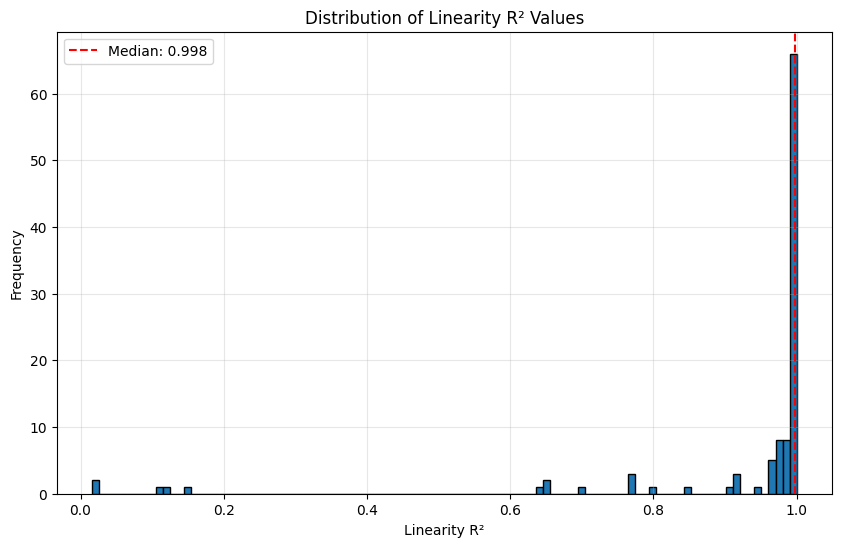


Linearity Statistics:
  Mean R²: 0.9251
  Median R²: 0.9980
  Objects with R² > 0.9: 92 (86.8%)
  Objects with R² > 0.95: 87 (82.1%)
  Objects with R² > 0.99: 68 (64.2%)


In [45]:
# Plot linearity distribution
plt.figure(figsize=(10, 6))
plt.hist(results["linearity_r2"], bins=100, edgecolor='black')
plt.xlabel("Linearity R²")
plt.ylabel("Frequency")
plt.title("Distribution of Linearity R² Values")
plt.axvline(results["linearity_r2"].median(), color='red', linestyle='--', label=f'Median: {results["linearity_r2"].median():.3f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Summary stats
print(f"\nLinearity Statistics:")
print(f"  Mean R²: {results['linearity_r2'].mean():.4f}")
print(f"  Median R²: {results['linearity_r2'].median():.4f}")
print(f"  Objects with R² > 0.9: {(results['linearity_r2'] > 0.9).sum()} ({100 * (results['linearity_r2'] > 0.9).mean():.1f}%)")
print(f"  Objects with R² > 0.95: {(results['linearity_r2'] > 0.95).sum()} ({100 * (results['linearity_r2'] > 0.95).mean():.1f}%)")
print(f"  Objects with R² > 0.99: {(results['linearity_r2'] > 0.99).sum()} ({100 * (results['linearity_r2'] > 0.99).mean():.1f}%)")

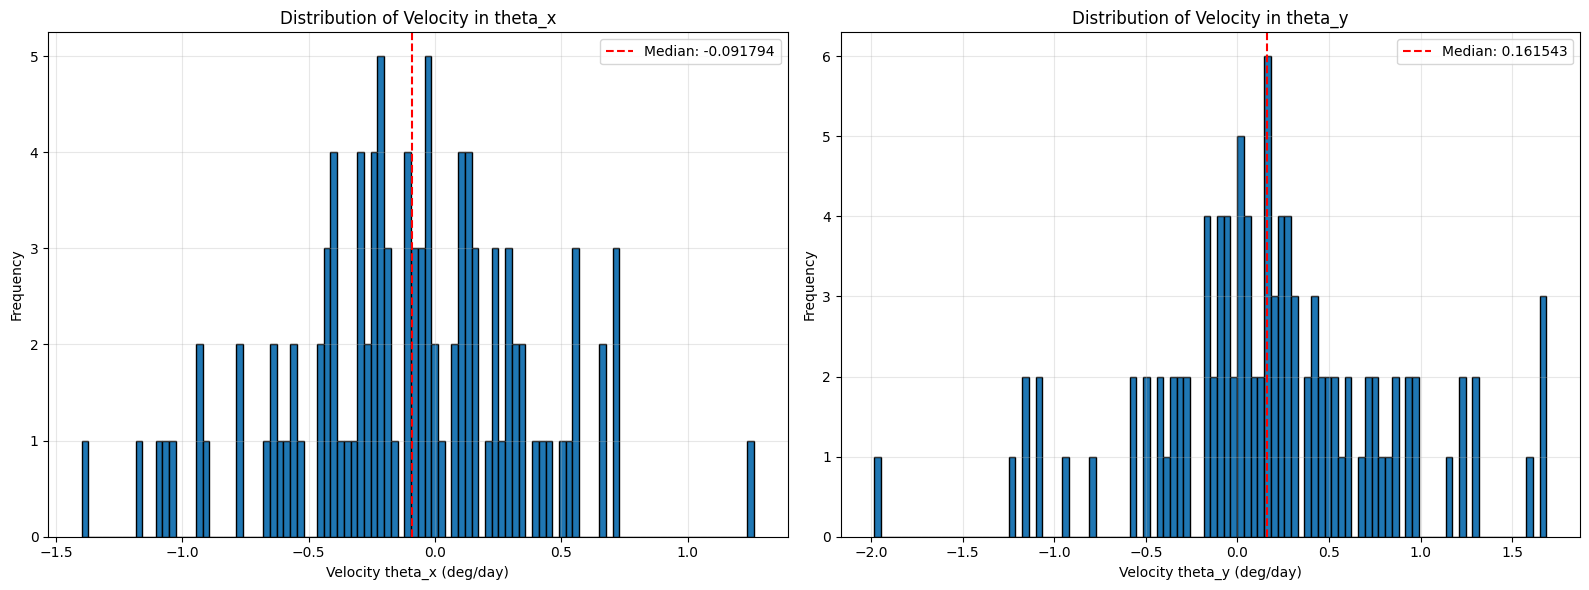

NameError: name 'np' is not defined

In [47]:
# Plot velocity distributions
fig, (ax1, ax2) = plt.subplots(1, 2, figsize=(16, 6))

# Velocity in theta_x
ax1.hist(results["velocity_theta_x"], bins=100, edgecolor='black')
ax1.set_xlabel("Velocity theta_x (deg/day)")
ax1.set_ylabel("Frequency")
ax1.set_title("Distribution of Velocity in theta_x")
ax1.axvline(results["velocity_theta_x"].median(), color='red', linestyle='--', 
            label=f'Median: {results["velocity_theta_x"].median():.6f}')
ax1.legend()
ax1.grid(alpha=0.3)

# Velocity in theta_y
ax2.hist(results["velocity_theta_y"], bins=100, edgecolor='black')
ax2.set_xlabel("Velocity theta_y (deg/day)")
ax2.set_ylabel("Frequency")
ax2.set_title("Distribution of Velocity in theta_y")
ax2.axvline(results["velocity_theta_y"].median(), color='red', linestyle='--',
            label=f'Median: {results["velocity_theta_y"].median():.6f}')
ax2.legend()
ax2.grid(alpha=0.3)

plt.tight_layout()
plt.show()

# Velocity magnitude
results_with_vmag = results.copy()
results_with_vmag["velocity_magnitude"] = np.sqrt(
    results_with_vmag["velocity_theta_x"]**2 + results_with_vmag["velocity_theta_y"]**2
)

plt.figure(figsize=(10, 6))
plt.hist(results_with_vmag["velocity_magnitude"], bins=100, edgecolor='black')
plt.xlabel("Velocity Magnitude (deg/day)")
plt.ylabel("Frequency")
plt.title("Distribution of Velocity Magnitude")
plt.axvline(results_with_vmag["velocity_magnitude"].median(), color='red', linestyle='--',
            label=f'Median: {results_with_vmag["velocity_magnitude"].median():.6f}')
plt.legend()
plt.grid(alpha=0.3)
plt.show()

# Velocity statistics
print(f"\nVelocity Statistics:")
print(f"  Mean velocity_theta_x: {results['velocity_theta_x'].mean():.6f} deg/day")
print(f"  Mean velocity_theta_y: {results['velocity_theta_y'].mean():.6f} deg/day")
print(f"  Mean velocity magnitude: {results_with_vmag['velocity_magnitude'].mean():.6f} deg/day")
print(f"  Median velocity magnitude: {results_with_vmag['velocity_magnitude'].median():.6f} deg/day")

## Shutdown Ray Connection

In [46]:
ray.shutdown()
print("Disconnected from Ray cluster")

Disconnected from Ray cluster
